# Predicting Employee Performance Using Machine Learning and Explainable Artificial Intelligence (XAI)

## Notebook 3 – Machine Learning Model Development

**Student:** Funwayo Nkhata

**Programme:** MSc Data Science

**Supervisor:** Dr Kat Fair

# Objective

The objective of this notebook is to develop, train and evaluate multiple supervised machine learning models capable of predicting employee performance.

The notebook compares the predictive performance of several classification algorithms using both encoded and scaled datasets where appropriate. Model performance is evaluated using multiple classification metrics, enabling the identification of the most suitable algorithm for predicting employee performance.

The findings from this notebook provide the foundation for the Explainable Artificial Intelligence (XAI) analysis presented in the subsequent notebook.

### Modelling Task: Classification Rather Than Regression

The original project proposal considered a regression-based approach to employee-performance prediction. However, subsequent examination of the dataset established that the target variable, `Performance_Score`, represents five discrete performance categories coded from 1 to 5 rather than a continuous measurement scale.

The analytical task was therefore reformulated as supervised multiclass classification. Treating the target as continuous within a conventional regression framework would imply equal numerical distances between adjacent performance categories and could generate predicted values that do not correspond directly to the observed classes. A classification framework instead predicts membership of the five defined performance categories and enables performance to be evaluated using classification-specific measures.

This represents a justified methodological development from the original proposal rather than a change in the underlying research objective. The study continues to investigate whether employee performance can be predicted from employee and organisational characteristics, but the modelling framework is aligned more closely with the structure of the available target variable.

# Import Required Libraries

The following libraries are imported to support machine learning model development, evaluation and performance comparison.

In [43]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Load Processed Datasets

The encoded and scaled datasets created during the preprocessing stage are loaded to support the development and comparison of multiple machine learning models.

In [44]:
X_train_encoded = pd.read_csv("../Processed_Data/X_train_encoded.csv")
X_test_encoded = pd.read_csv("../Processed_Data/X_test_encoded.csv")

X_train_scaled = pd.read_csv("../Processed_Data/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../Processed_Data/X_test_scaled.csv")

y_train = pd.read_csv("../Processed_Data/y_train.csv").squeeze()

y_test = pd.read_csv("../Processed_Data/y_test.csv").squeeze()

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Verify the Loaded Datasets

In [45]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(80000, 29)
(20000, 29)
(80000, 29)
(20000, 29)


# Baseline Model

A baseline model is developed to provide a simple benchmark for comparison with the machine learning models. The baseline approach predicts the most frequent class in the training target variable.

This helps determine whether more advanced models provide meaningful improvement beyond a simple majority-class prediction.

In [46]:
# Check the distribution of the target variable in the training set

y_train.value_counts().sort_index()

Performance_Score
1    16096
2    16010
3    15999
4    15952
5    15943
Name: count, dtype: int64

In [47]:
# Create a baseline prediction using the most common class

baseline_class = y_train.mode()[0]

baseline_predictions = [baseline_class] * len(y_test)

print("Most common class:", baseline_class)

Most common class: 1


In [48]:
# Evaluate baseline model

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions, average="weighted", zero_division=0)
baseline_recall = recall_score(y_test, baseline_predictions, average="weighted", zero_division=0)
baseline_f1 = f1_score(y_test, baseline_predictions, average="weighted", zero_division=0)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1 Score:", baseline_f1)

Baseline Accuracy: 0.2012
Baseline Precision: 0.04048144
Baseline Recall: 0.2012
Baseline F1 Score: 0.067401665001665


### Interpretation

The majority-class classifier predicts the most frequently occurring training-set category, `Performance_Score = 1`, for every held-out observation. It therefore provides a simple empirical benchmark against which the supervised machine-learning models can be compared.

The baseline achieved a held-out accuracy of 20.12%. Because the five target categories are approximately balanced, this value is also numerically close to the 20% expected accuracy of uniform random guessing across five classes. However, the two concepts should not be conflated: the baseline is a deterministic majority-class classifier rather than a random classifier.

The low weighted precision and F1-score arise because the baseline predicts only one category and therefore provides no discriminatory capability for the remaining four performance classes. Its purpose is not to provide a useful predictive model, but to establish the minimum empirical benchmark that more sophisticated classifiers should meaningfully exceed.

Consequently, subsequent models are evaluated not simply according to their absolute accuracy, but according to whether they provide a substantive improvement over the 20.12% majority-class benchmark.

# Logistic Regression

Logistic Regression is selected as the first supervised machine learning algorithm because it provides a simple yet effective baseline classification model. Although originally developed for binary classification, the algorithm can be extended to multiclass problems using a multinomial approach.

The model is trained using the scaled dataset because Logistic Regression is sensitive to differences in feature magnitude. Standardising the numerical features improves numerical stability and supports more reliable model optimisation.

In [49]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [50]:
# Predict the test set

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [51]:
# Evaluate Logistic Regression

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

Accuracy : 0.2023
Precision: 0.2017
Recall   : 0.2023
F1 Score : 0.1995


In [52]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           1       0.20      0.25      0.22      4024
           2       0.19      0.17      0.18      4003
           3       0.21      0.27      0.24      4000
           4       0.21      0.16      0.18      3988
           5       0.20      0.16      0.17      3985

    accuracy                           0.20     20000
   macro avg       0.20      0.20      0.20     20000
weighted avg       0.20      0.20      0.20     20000



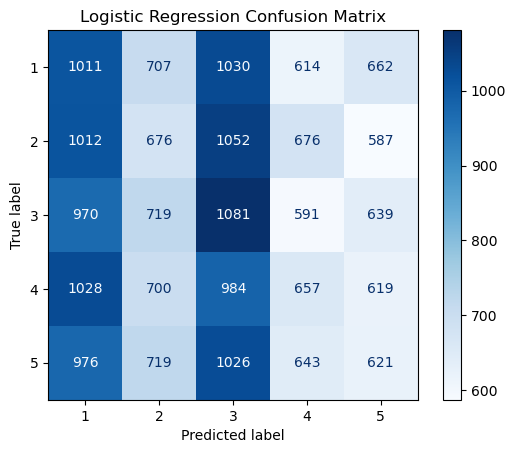

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix indicates that the Logistic Regression model has limited ability to distinguish between the five employee performance classes. Although correct classifications are present along the principal diagonal, substantial off-diagonal values demonstrate frequent misclassification across all categories.

The relatively dispersed distribution of predictions is consistent with the classification metrics, with held-out accuracy of 20.23%, only marginally above the 20.12% majority-class baseline.

These results indicate that, under the current model specification, Logistic Regression identifies limited discriminatory information within the refined predictor set. The result should not be interpreted as demonstrating that employee performance is inherently unpredictable; rather, the evaluated linear model does not substantially outperform the empirical baseline using the available predictors.

### Overall Model Interpretation

The Logistic Regression model achieved an accuracy of 20.23%, representing only a marginal numerical improvement over the majority-class baseline of 20.12%. Precision, recall and weighted F1-score were similarly modest, indicating limited discriminatory capability within the held-out test data.

Because Logistic Regression estimates linear decision boundaries, these findings indicate that the refined predictor set provides little linear separation between the five `Performance_Score` categories under the current model specification.

Logistic Regression nevertheless provides an important benchmark because of its relative simplicity and interpretability. Its performance establishes a useful reference against which more flexible non-linear and ensemble classifiers can subsequently be evaluated.

In [54]:
# Check the predictor columns

print(X_train_scaled.columns.tolist())

['Age', 'Years_At_Company', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Employee_Satisfaction_Score', 'Department_Engineering', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Legal', 'Department_Marketing', 'Department_Operations', 'Department_Sales', 'Gender_Male', 'Gender_Other', 'Job_Title_Consultant', 'Job_Title_Developer', 'Job_Title_Engineer', 'Job_Title_Manager', 'Job_Title_Specialist', 'Job_Title_Technician', 'Education_Level_High School', 'Education_Level_Master', 'Education_Level_PhD']


### Interpretation of Model Performance

The substantial reduction in predictive performance relative to the initial diagnostic models demonstrates the importance of predictor validity within the modelling process.

Notebook 2 established that the initially perfect Decision Tree performance was overwhelmingly dependent on `Monthly_Salary`, while `Promotions` and `Resigned` presented additional temporal or conceptual-validity concerns. These variables were therefore excluded from the refined predictor set before comparative model development.

Following this refinement, Logistic Regression achieved approximately 20% held-out accuracy. The lower performance should not be interpreted as a methodological weakness. Instead, it provides a more conservative assessment of predictive capability using predictors considered more defensible for prospective employee-performance prediction.

The subsequent modelling stages therefore investigate whether alternative algorithms with different learning assumptions can extract stronger predictive information from the same refined feature set.

### Critical Discussion and Limitations

The modest predictive performance observed for Logistic Regression indicates that the available refined predictors provide limited linear discriminatory information for the five employee performance categories.

However, this result should be interpreted within the scope of the available synthetic dataset and the evaluated model specification. Employee performance may be associated with organisational, behavioural, managerial and longitudinal factors that are not represented within the available variables. Consequently, the present analysis cannot establish that employee performance is inherently unpredictable.

The result also highlights the distinction between predictive accuracy and methodological validity. Retaining variables that provide exceptionally strong target-related information may increase apparent accuracy while weakening the prospective interpretation of the model. The refined feature set therefore prioritises predictor validity over maximising apparent predictive performance.

Further models with different learning mechanisms are evaluated to determine whether non-linear, ensemble and margin-based approaches can identify additional predictive structure within the same refined feature set.

# Decision Tree Classifier

Having established Logistic Regression as the initial benchmark model, the next stage of the analysis evaluates a Decision Tree classifier. Unlike Logistic Regression, Decision Trees are non-linear machine learning algorithms capable of modelling complex decision boundaries without requiring feature scaling.

The Decision Tree is trained using the encoded dataset generated during the preprocessing stage. Its predictive performance is evaluated using the same classification metrics to ensure a fair comparison with the Logistic Regression model.

In [55]:
# Train Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train_encoded, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [56]:
# Predict the test data

y_pred_tree = decision_tree.predict(X_test_encoded)

In [57]:
# Evaluate Decision Tree

tree_accuracy = accuracy_score(y_test, y_pred_tree)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    average="weighted"
)

print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

Accuracy : 0.2000
Precision: 0.2000
Recall   : 0.2000
F1 Score : 0.2000


In [58]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           1       0.20      0.19      0.20      4024
           2       0.20      0.20      0.20      4003
           3       0.20      0.20      0.20      4000
           4       0.20      0.20      0.20      3988
           5       0.20      0.20      0.20      3985

    accuracy                           0.20     20000
   macro avg       0.20      0.20      0.20     20000
weighted avg       0.20      0.20      0.20     20000



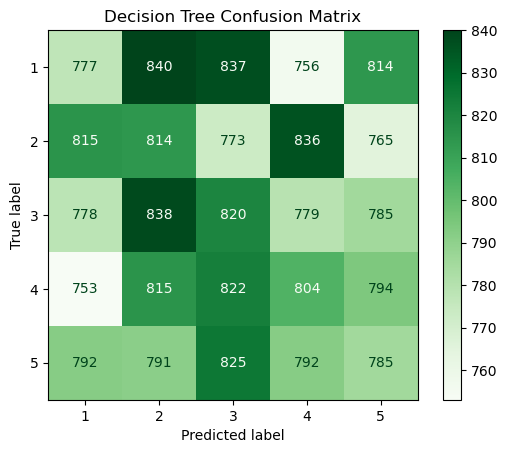

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix illustrates the classification performance of the Decision Tree model across all five employee performance categories.

The matrix shows the number of correctly and incorrectly classified observations for each performance class. High values along the diagonal indicate accurate classification, while any off-diagonal values represent misclassified observations.

The confusion matrix provides a visual assessment of the model's predictive capability and complements the evaluation metrics reported in the classification report.

## Overall Model Interpretation

The Decision Tree classifier achieved an overall accuracy of 20.00%, with corresponding precision, recall and weighted F1-score values of approximately 20%. This performance was broadly consistent with the approximately balanced five-class structure and slightly below the 20.12% majority-class baseline.

The classification report and confusion matrix indicate substantial misclassification across all employee performance categories. Although the Decision Tree correctly classified a proportion of observations within each class, no performance category was predicted with consistently high accuracy. This suggests that the remaining predictor variables contain insufficient discriminatory information to reliably distinguish between employee performance levels.

Unlike Logistic Regression, Decision Trees do not assume linear relationships between predictor variables and the target variable. Instead, they recursively partition the feature space into increasingly homogeneous groups using a sequence of decision rules. This enables Decision Trees to capture complex non-linear relationships and interactions between variables without requiring feature scaling.

Despite these theoretical advantages, the Decision Tree classifier did not substantially outperform the Logistic Regression model. This finding suggests that the principal limitation lies not in the modelling algorithm itself but in the predictive information contained within the refined feature set. Following the removal of variables associated with potential target leakage, the remaining demographic, organisational and behavioural variables provide only weak signals for predicting employee performance.

From a methodological perspective, these findings strengthen the validity of the study. Although predictive performance decreased considerably following the removal of leakage-prone variables, the revised modelling framework provides a more realistic assessment of employee performance prediction using information that would genuinely be available before performance evaluation. Consequently, the results should be interpreted as demonstrating the challenges of predicting employee performance from pre-performance organisational data rather than reflecting limitations of the Decision Tree algorithm itself.

### Comparison with Logistic Regression

The Decision Tree and Logistic Regression produced broadly comparable held-out predictive performance, although their results were not identical. Logistic Regression achieved an accuracy of 20.23%, compared with 20.00% for the Decision Tree, while the remaining weighted evaluation metrics were similarly close.

This similarity is noteworthy because the algorithms represent substantially different modelling approaches. Logistic Regression estimates linear decision boundaries within the transformed feature space, whereas a Decision Tree recursively partitions the predictor space and can represent non-linear relationships and feature interactions.

Despite these differences, neither algorithm materially exceeded the 20.12% majority-class baseline. The result therefore provides preliminary evidence that changing from a linear to a flexible non-linear classifier does not substantially improve predictive performance using the refined predictor set.

However, performance from two algorithms alone is insufficient to attribute the result definitively to the available features. Additional ensemble and margin-based classifiers are therefore evaluated in subsequent sections.

# 9 Random Forest Classifier

Following the evaluation of the Decision Tree classifier, the next stage of the analysis investigates the performance of a Random Forest classifier.

Random Forest is an ensemble learning algorithm that constructs a large number of decision trees during training and combines their predictions using majority voting. This ensemble approach generally produces more robust and accurate predictions than a single Decision Tree by reducing model variance and mitigating overfitting.

Unlike Logistic Regression, Random Forest does not assume linear relationships between predictor variables and the target variable. Furthermore, because the algorithm is based on decision trees, feature scaling is unnecessary. Consequently, the encoded dataset generated during the preprocessing stage is used for model development.

The model is evaluated using the same performance metrics as the previous algorithms, including accuracy, precision, recall and weighted F1-score. This ensures a fair comparison across all machine learning models developed within this study.

In [60]:
# Train Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train_encoded, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
# Predict the test data

y_pred_rf = random_forest.predict(X_test_encoded)

In [62]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.2037
Precision: 0.2037
Recall   : 0.2037
F1 Score : 0.2033


In [63]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.20      0.22      0.21      4024
           2       0.20      0.22      0.21      4003
           3       0.21      0.21      0.21      4000
           4       0.20      0.19      0.20      3988
           5       0.20      0.18      0.19      3985

    accuracy                           0.20     20000
   macro avg       0.20      0.20      0.20     20000
weighted avg       0.20      0.20      0.20     20000



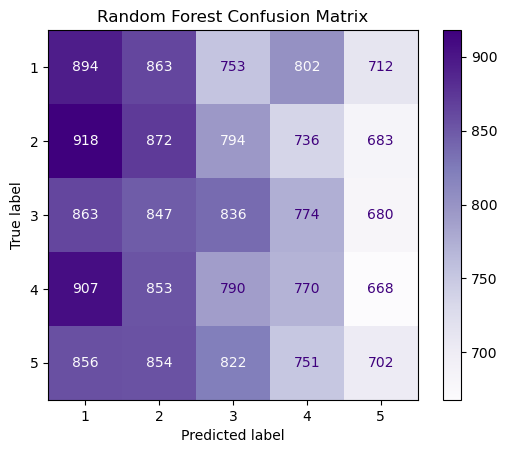

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Purples"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix provides a visual assessment of the Random Forest classifier's predictive performance across the five employee performance categories. Unlike an ideal classifier, where the majority of observations would be concentrated along the principal diagonal, the predictions are distributed across both the diagonal and off-diagonal cells, indicating substantial misclassification between performance categories.

Although the Random Forest classifier correctly identifies a proportion of observations within each class, the similarity between the diagonal and off-diagonal frequencies demonstrates that the model has limited ability to distinguish reliably between the five employee performance categories. Misclassification occurs across all classes, suggesting that the remaining predictor variables do not contain sufficiently distinctive information to support accurate classification.

Compared with the Decision Tree classifier, Random Forest provides only a marginal improvement in predictive performance despite combining the predictions of multiple decision trees through ensemble learning. This finding suggests that increasing model complexity alone does not substantially improve classification accuracy when the underlying predictor variables contain limited predictive information.

The confusion matrix supports the quantitative evaluation metrics, where the Random Forest classifier achieved an accuracy of **20.37%**, only marginally higher than the baseline classifier (**20.12%**). From a methodological perspective, these findings indicate that the reduced predictive performance is primarily attributable to the removal of variables associated with potential target leakage rather than limitations of the Random Forest algorithm itself.

Overall, the confusion matrix provides further evidence that employee performance is a complex organisational outcome that cannot be accurately predicted using the available pre-performance demographic and organisational variables alone. Additional behavioural, managerial or longitudinal employee information would likely be required to achieve substantially higher predictive performance in real organisational settings.

### Overall Model Interpretation

The Random Forest classifier achieved an accuracy of 20.37%, with corresponding weighted precision and recall of 20.37% and a weighted F1-score of 20.33%. This represents the highest held-out accuracy among the models evaluated at this stage, but only a 0.25 percentage-point numerical improvement over the 20.12% majority-class baseline.

Random Forest can model non-linear relationships and interactions through an ensemble of decision trees. Despite this additional flexibility, the observed improvement over both the baseline and simpler classifiers is small.

The result therefore provides further evidence that increasing model complexity does not substantially improve held-out predictive performance under the current feature set. However, a single held-out comparison is insufficient to determine whether these small differences represent stable differences between algorithms.

Cross-validation is therefore used later in the notebook to examine model performance across multiple training-validation partitions before the model used for subsequent explainability analysis is determined.

## Comparison with Previous Models

The Random Forest classifier achieved the highest predictive performance among the models evaluated to this point, with an overall **accuracy of 20.37%**. However, the improvement over both **Logistic Regression** and the **Decision Tree** classifier was extremely small, indicating that increasing model complexity resulted in only marginal gains in predictive performance.

The similarity in performance across these fundamentally different algorithms suggests that the primary limitation lies not in the choice of machine learning algorithm but in the predictive information contained within the available features. Despite its ability to model complex non-linear relationships and interactions between variables, the Random Forest classifier was unable to identify substantially more informative patterns than either the linear Logistic Regression model or the single Decision Tree.

From a methodological perspective, Random Forest retains several important advantages. By combining multiple decision trees through bootstrap aggregation (bagging) and random feature selection, the algorithm generally produces more stable predictions and is less susceptible to overfitting than an individual Decision Tree. Nevertheless, these advantages cannot compensate for limited predictive information within the underlying dataset.

The consistently modest predictive performance observed across the evaluated models reinforces an important finding of this study. Following the removal of variables associated with potential target leakage, the remaining demographic, organisational and behavioural variables provide only weak predictive signals for employee performance. This suggests that improving predictive performance is likely to require richer employee data, such as behavioural metrics, competency assessments, managerial evaluations or longitudinal performance histories, rather than increasingly sophisticated machine learning algorithms.

Consequently, although Random Forest represents the strongest-performing model evaluated so far, the difference in performance is unlikely to be practically significant. Model selection should therefore consider not only predictive accuracy but also model robustness, interpretability and suitability for subsequent Explainable Artificial Intelligence (XAI) analysis.

## Implications for Employee Performance Prediction

The findings indicate that, following the removal of variables associated with potential target leakage, the available demographic, organisational and behavioural characteristics provide only limited predictive information for employee performance. Although the Random Forest classifier marginally outperformed the other evaluated algorithms, the improvement over the baseline classifier was small, suggesting that the available predictors are insufficient for reliable employee performance classification.

These results demonstrate an important principle of predictive analytics: increasing algorithmic complexity does not necessarily improve predictive performance when the underlying data contain weak relationships with the target variable. Despite Random Forest's ability to model complex non-linear interactions and reduce variance through ensemble learning, the algorithm was unable to identify sufficiently informative patterns within the refined feature set.

From an organisational perspective, the findings suggest that employee performance is influenced by a wider range of factors than those represented within the current synthetic dataset. Variables such as leadership quality, employee engagement, competency assessments, behavioural indicators, organisational culture, communication patterns and longitudinal performance histories may provide substantially greater predictive value than demographic or structural employee characteristics alone.

Although the predictive performance achieved in this study is modest, the findings remain valuable because they demonstrate the importance of rigorous feature selection and methodological validity in machine learning. Rather than relying on variables that may inadvertently encode the target outcome, the revised modelling framework provides a more realistic assessment of the challenges associated with predicting employee performance in real organisational environments.

For practical Human Resource Analytics, these findings suggest that predictive models should be viewed as decision-support tools rather than decision-making systems. Any implementation should therefore be accompanied by appropriate governance, human oversight, transparency, fairness assessments and ethical safeguards to ensure that machine learning complements, rather than replaces, professional managerial judgement.

# XGBoost Classifier

The next stage of the analysis evaluates the performance of the eXtreme Gradient Boosting (XGBoost) classifier.

XGBoost is an advanced ensemble learning algorithm based on gradient boosting, where decision trees are built sequentially rather than independently. Each successive tree is trained to minimise the errors made by the previous trees, allowing the model to progressively improve predictive performance.

XGBoost has become one of the most widely used machine learning algorithms for structured tabular datasets due to its high predictive accuracy, computational efficiency and ability to model complex non-linear relationships. The algorithm also incorporates regularisation techniques that help reduce overfitting while maintaining excellent predictive capability.

As with the Decision Tree and Random Forest models, XGBoost does not require feature scaling. Consequently, the encoded dataset produced during the preprocessing stage is used for model development.

The model is evaluated using accuracy, precision, recall and weighted F1-score to ensure direct comparison with the previously developed machine learning algorithms.

In [65]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [66]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train_encoded,
    y_train - 1
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [67]:
y_pred_xgb = xgb_model.predict(X_test_encoded)

y_pred_xgb = y_pred_xgb + 1

In [68]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, average="weighted")
xgb_recall = recall_score(y_test, y_pred_xgb, average="weighted")
xgb_f1 = f1_score(y_test, y_pred_xgb, average="weighted")

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

Accuracy : 0.2025
Precision: 0.2025
Recall   : 0.2025
F1 Score : 0.2025


In [69]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           1       0.20      0.20      0.20      4024
           2       0.20      0.20      0.20      4003
           3       0.21      0.22      0.22      4000
           4       0.20      0.20      0.20      3988
           5       0.21      0.20      0.20      3985

    accuracy                           0.20     20000
   macro avg       0.20      0.20      0.20     20000
weighted avg       0.20      0.20      0.20     20000



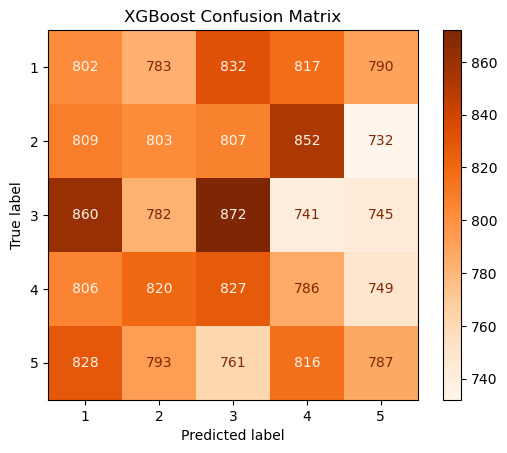

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix provides a visual assessment of the XGBoost classifier's predictive performance across the five employee performance categories. In an ideal classification model, the majority of observations would be concentrated along the principal diagonal, indicating correct predictions. However, the confusion matrix demonstrates that predictions are distributed across both the diagonal and off-diagonal cells, indicating substantial misclassification between all performance categories.

Although the classifier correctly identifies a proportion of observations within each class, the relatively similar frequencies observed throughout the matrix indicate that XGBoost has limited ability to distinguish reliably between the five employee performance levels. No single performance category is classified substantially better than the others, which is consistent with the balanced precision, recall and F1-scores reported in the classification report.

The confusion matrix supports the quantitative evaluation metrics, where XGBoost achieved an overall **accuracy of 20.25%**, only marginally higher than the baseline classifier (**20.12%**). Despite the algorithm's ability to model highly complex non-linear relationships through sequential gradient boosting, the available predictor variables contain insufficient information to support accurate classification of employee performance.

From a methodological perspective, these findings provide further evidence that the removal of variables associated with potential target leakage resulted in a more realistic modelling framework. The observed performance reflects the genuine predictive capability of the remaining organisational and employee characteristics rather than artificially inflated accuracy resulting from variables that may encode the target outcome.

Overall, the confusion matrix reinforces one of the principal findings of this study: employee performance represents a complex organisational outcome that cannot be accurately predicted using the available pre-performance demographic, organisational and behavioural variables alone. Future predictive models would likely benefit from incorporating richer behavioural, managerial and longitudinal employee information.

## Overall Model Interpretation

The XGBoost classifier achieved an overall **accuracy of 20.25%**, with corresponding **precision, recall and weighted F1-score values of 20.25%**. The classification report indicates consistently modest predictive performance across all five employee performance categories, with no individual class demonstrating substantially higher predictive accuracy than the others.

Unlike Random Forest, which constructs multiple independent decision trees using bootstrap aggregation, XGBoost builds its ensemble sequentially by fitting each new tree to the residual errors generated by previous trees. This gradient boosting approach enables the algorithm to model complex non-linear relationships while incorporating regularisation techniques that improve model robustness and reduce the risk of overfitting.

Despite these methodological advantages, XGBoost achieved predictive performance that was comparable to the other evaluated machine learning algorithms. This finding suggests that the principal limitation lies not in the predictive capability of the algorithm but in the information available within the refined predictor set. Following the removal of variables associated with potential target leakage, the remaining demographic, organisational and behavioural variables provide only weak predictive signals for employee performance.

From a methodological perspective, these findings strengthen the validity of the study. Rather than producing artificially inflated performance through the inclusion of variables that may encode the target outcome, the revised modelling framework provides a more realistic assessment of employee performance prediction using information that would genuinely be available before performance evaluation.

Although the predictive performance achieved by XGBoost is modest, the algorithm remains an appropriate candidate for Explainable Artificial Intelligence (XAI) analysis because it provides robust modelling of structured tabular data and integrates effectively with SHAP (SHapley Additive exPlanations). Consequently, subsequent explainability analysis will focus on understanding how the refined predictor variables influence model predictions rather than simply identifying the highest-performing classifier.

## Comparison with Previous Models

The XGBoost classifier achieved predictive performance comparable to the other evaluated machine learning algorithms, with an overall **accuracy of 20.25%**. Although its performance was similar to that of Logistic Regression, Decision Tree and Support Vector Machine, it was marginally outperformed by the Random Forest classifier, which achieved the highest overall accuracy (**20.37%**). However, these differences were extremely small and are unlikely to be practically significant.

The consistently modest predictive performance observed across fundamentally different modelling approaches—including linear, tree-based, bagging and gradient boosting algorithms—suggests that the principal limitation lies not in algorithm selection but in the predictive information available within the refined feature set. Despite their differing mathematical foundations and learning mechanisms, none of the evaluated algorithms was able to identify sufficiently informative patterns to accurately distinguish between the five employee performance categories.

These findings reinforce an important methodological conclusion. Following the removal of variables associated with potential target leakage, the remaining demographic, organisational and behavioural characteristics provide only weak predictive signals for employee performance. Consequently, increasing model complexity alone does not substantially improve predictive performance when the underlying predictor variables contain limited explanatory power.

Although XGBoost did not achieve the highest predictive accuracy, it remains one of the most appropriate models for subsequent Explainable Artificial Intelligence (XAI) analysis. Its ability to model complex non-linear relationships, together with its seamless integration with SHAP (SHapley Additive exPlanations), enables comprehensive global and local interpretation of model behaviour. Therefore, the final model selection is based not solely on predictive performance but also on methodological robustness, interpretability and suitability for explainable machine learning.

## Implications for Employee Performance Prediction

The findings indicate that, following the removal of variables associated with potential target leakage, the available demographic, organisational and behavioural characteristics provide only limited predictive information for employee performance. Although XGBoost is recognised as one of the most powerful machine learning algorithms for structured tabular data, its predictive performance remained comparable to the other evaluated models, suggesting that the principal limitation lies within the available features rather than the algorithm itself.

These results reinforce an important principle of predictive analytics: increasing algorithmic sophistication cannot compensate for limited feature quality. Despite XGBoost's ability to model complex non-linear relationships through gradient boosting, the refined predictor variables contained insufficient information to accurately distinguish between the five employee performance categories.

From an organisational perspective, the findings suggest that reliable prediction of employee performance is likely to require richer and more informative data than those available within the current dataset. Variables such as competency assessments, behavioural indicators, leadership evaluations, employee engagement measures, communication patterns and longitudinal performance histories may provide substantially greater predictive value than demographic and structural employee characteristics alone.

Although the predictive performance achieved in this study is modest, the research provides an important methodological contribution by demonstrating the value of rigorous feature selection and the prevention of target leakage. The revised modelling framework provides a more realistic assessment of employee performance prediction than models that achieve artificially high accuracy through the inclusion of variables that may inadvertently encode the target outcome.

From a practical Human Resource Analytics perspective, predictive models should therefore be viewed as decision-support tools rather than automated decision-making systems. Any organisational implementation should incorporate appropriate governance, transparency, fairness assessments, human oversight and Explainable Artificial Intelligence (XAI) to ensure that predictive insights complement professional managerial judgement and support ethical workforce management.

# Support Vector Machine

The final machine learning algorithm evaluated in this study is a Support Vector Machine (SVM) classifier.

Support Vector Machines are supervised learning algorithms that identify decision boundaries by maximising the margin between classes. Unlike tree-based models, SVMs are sensitive to the scale of predictor variables. Therefore, the scaled dataset produced during preprocessing is used for this model.

The standard RBF-kernel SVM was not used because it is computationally expensive for large datasets such as this one, which contains 80,000 training observations. Instead, a Linear SVM is applied. This provides a computationally efficient margin-based classifier while still adding methodological diversity to the model comparison.

In [71]:
from sklearn.svm import LinearSVC

In [72]:
linear_svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

linear_svm.fit(X_train_scaled, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [73]:
y_pred_svm = linear_svm.predict(X_test_scaled)

In [74]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average="weighted")
svm_recall = recall_score(y_test, y_pred_svm, average="weighted")
svm_f1 = f1_score(y_test, y_pred_svm, average="weighted")

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Accuracy : 0.2026
Precision: 0.2020
Recall   : 0.2026
F1 Score : 0.2001


In [75]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           1       0.20      0.25      0.23      4024
           2       0.19      0.17      0.18      4003
           3       0.21      0.26      0.23      4000
           4       0.21      0.16      0.18      3988
           5       0.20      0.16      0.18      3985

    accuracy                           0.20     20000
   macro avg       0.20      0.20      0.20     20000
weighted avg       0.20      0.20      0.20     20000



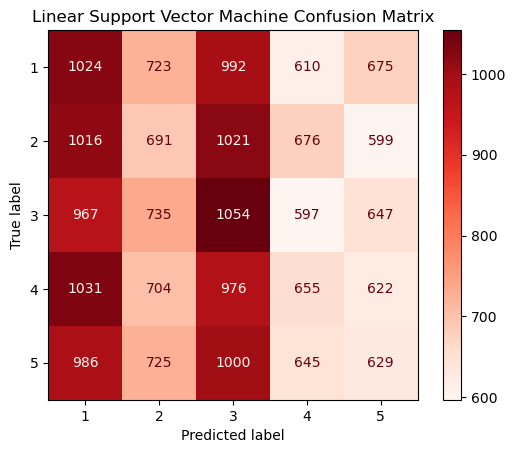

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    cmap="Reds"
)

plt.title("Linear Support Vector Machine Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix provides a visual assessment of the Linear Support Vector Machine's classification performance across the five employee performance categories. In an ideal classifier, the majority of observations would be concentrated along the principal diagonal, indicating correct classification. However, the confusion matrix demonstrates substantial off-diagonal predictions, indicating frequent misclassification between all performance categories.

Although the model correctly classifies a proportion of observations within each class, the distribution of predictions across the matrix indicates limited discriminatory capability. Consistent with the classification report, Performance Scores **1** and **3** achieved marginally higher recall values than the remaining classes, whereas Performance Scores **2**, **4** and **5** exhibited lower recall, demonstrating greater difficulty in correctly identifying these employee performance categories. Nevertheless, the differences between classes are relatively modest, suggesting that no single performance category is consistently distinguishable from the others.

The confusion matrix supports the quantitative evaluation metrics, where the Linear Support Vector Machine achieved an overall **accuracy of 20.26%**, only slightly above the baseline classifier (**20.12%**). Despite the theoretical capability of Support Vector Machines to identify optimal decision boundaries within transformed feature spaces, the available predictor variables provide insufficient discriminatory information to separate employee performance categories effectively.

Importantly, the similarity between the confusion matrices produced by the Linear Support Vector Machine and the previously evaluated algorithms reinforces a key finding of this study. Regardless of whether the classifier employs linear decision boundaries, individual decision trees, ensemble bagging or gradient boosting, predictive performance remains consistently modest. This provides further evidence that, within the evaluated modelling framework, the principal limitation lies within the available predictor variables rather than the choice of machine learning algorithm.

Overall, the confusion matrix further supports the conclusion that employee performance is a complex organisational outcome that cannot be accurately predicted using the available pre-performance demographic, organisational and behavioural variables alone. Future research is therefore likely to benefit more from richer feature engineering and improved data collection than from increasing algorithmic complexity.

### Overall Model Interpretation

The Linear Support Vector Machine (SVM) achieved an overall **accuracy of 20.26%**, with a weighted **precision of 20.20%**, **recall of 20.26%** and **F1-score of 20.01%**. These results indicate limited discriminatory capability and performance broadly comparable with the other machine-learning algorithms evaluated in this study.

The classification report demonstrates relatively balanced performance across the five employee performance categories, although some variation exists between individual classes. Performance Scores **1** and **3** achieved comparatively higher recall values, whereas the remaining categories exhibited lower recall. Nevertheless, the differences between classes are relatively modest, and the model does not demonstrate consistently strong discrimination for any particular performance category.

Unlike the tree-based algorithms evaluated previously, the Linear SVM constructs linear decision boundaries that maximise class separation within the transformed feature space. Its performance therefore provides an additional assessment of whether the refined predictors contain sufficient discriminatory information to separate the five performance categories using a margin-based linear classification approach.

The held-out accuracy of **20.26%** represents only a **0.14 percentage-point improvement** over the **20.12% majority-class baseline**. This small difference does not, by itself, provide evidence of a meaningful improvement in predictive capability. Instead, the result indicates that the Linear SVM identifies limited discriminatory information within the refined predictor set under the current model specification.

Importantly, this result should not be interpreted as demonstrating that employee performance is inherently unpredictable or that the SVM algorithm itself is unsuitable. Rather, it indicates that this model, using the available synthetic predictors, does not substantially outperform the empirical baseline. Comparative cross-validation is therefore used subsequently to assess whether the small performance differences observed between the evaluated algorithms remain consistent across alternative training-validation partitions.

## Comparison with Previous Models

The Linear Support Vector Machine achieved predictive performance comparable to the other supervised machine learning algorithms evaluated in this study, with an overall **accuracy of 20.26%**. Although Random Forest produced the highest overall accuracy (**20.37%**), the differences between all evaluated models were extremely small and are unlikely to be of practical significance.

The consistency observed across fundamentally different machine learning algorithms—including Logistic Regression, Decision Tree, Random Forest, XGBoost and Linear Support Vector Machine—suggests that the principal limitation lies not in the choice of classification algorithm but in the predictive information available within the refined feature set. Despite employing different mathematical principles and learning mechanisms, all models produced remarkably similar predictive performance.

From a methodological perspective, these findings demonstrate that increasing algorithmic complexity does not necessarily improve predictive capability when the available predictor variables contain limited discriminatory information. Following the removal of variables associated with potential target leakage, the remaining demographic, organisational and behavioural characteristics provide only weak predictive signals for employee performance.

Importantly, the inclusion of the Linear Support Vector Machine strengthens the methodological rigour of this dissertation by extending the comparison beyond tree-based and linear regression models. Evaluating algorithms with fundamentally different modelling assumptions provides greater confidence that the consistently modest predictive performance reflects the characteristics of the available data rather than limitations associated with any individual machine learning technique.

These findings reinforce one of the principal conclusions of this study: improvements in employee performance prediction are more likely to be achieved through richer feature engineering, improved organisational data collection and the inclusion of additional behavioural and longitudinal variables than through the selection of increasingly sophisticated machine learning algorithms alone.

## Implications for Employee Performance Prediction

The findings indicate that algorithm selection alone has only a limited influence on predictive performance when the available predictor variables contain weak discriminatory information. Despite employing fundamentally different learning mechanisms, all evaluated machine learning algorithms achieved remarkably similar predictive performance, suggesting that the principal limitation lies within the available feature set rather than the choice of classification algorithm.

From an organisational perspective, these findings highlight the importance of data quality, feature engineering and variable selection in predictive Human Resource Analytics. Improving prediction accuracy is likely to depend more on incorporating richer organisational information—such as employee engagement measures, competency assessments, leadership evaluations, behavioural indicators and longitudinal performance histories—than on adopting increasingly sophisticated machine learning algorithms.

The study therefore demonstrates an important methodological principle: predictive success is driven not only by model selection but also by the quality, relevance and temporal availability of the predictor variables. Careful feature selection, combined with the exclusion of variables that may introduce target leakage, provides a more realistic and trustworthy assessment of predictive capability, even when this results in lower classification accuracy.

For practical organisational applications, machine learning models should therefore be viewed as decision-support tools rather than automated decision-making systems. Any implementation should incorporate appropriate governance, transparency, fairness assessments and Explainable Artificial Intelligence (XAI) to ensure that predictive insights complement human expertise and support ethical workforce management.

In [77]:
# Create comparison table

comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Linear SVM"
    ],

    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        xgb_accuracy,
        svm_accuracy
    ],

    "Precision": [
        baseline_precision,
        logistic_precision,
        tree_precision,
        rf_precision,
        xgb_precision,
        svm_precision
    ],

    "Recall": [
        baseline_recall,
        logistic_recall,
        tree_recall,
        rf_recall,
        xgb_recall,
        svm_recall
    ],

    "F1 Score": [
        baseline_f1,
        logistic_f1,
        tree_f1,
        rf_f1,
        xgb_f1,
        svm_f1
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.2012,0.0405,0.2012,0.0674
1,Logistic Regression,0.2023,0.2017,0.2023,0.1995
2,Decision Tree,0.2000,0.2000,0.2000,0.2000
3,Random Forest,0.2037,0.2037,0.2037,0.2033
4,XGBoost,0.2025,0.2025,0.2025,0.2025
5,Linear SVM,0.2026,0.2020,0.2026,0.2001


## Comparative Evaluation of Machine Learning Models

The predictive performance of all supervised machine learning algorithms developed within this study was evaluated using four standard classification metrics: **accuracy**, **precision**, **recall** and the **weighted F1-score**. These complementary measures provide a balanced assessment of model performance by considering both overall classification accuracy and the ability of each algorithm to correctly classify observations across all employee performance categories.

Comparing multiple machine learning algorithms represents an important methodological component of supervised learning because different algorithms employ fundamentally different mathematical principles and learning strategies. Evaluating a diverse range of linear, tree-based and ensemble models therefore enables a robust assessment of whether predictive performance is primarily influenced by algorithm selection or by the predictive information contained within the available features.

Following the removal of variables associated with potential target leakage during the preprocessing stage, the comparative evaluation presented in this section provides an objective assessment of each algorithm's ability to predict employee performance using only information that would realistically be available prior to performance assessment. Consequently, the comparison provides an assessment of relative model performance while also providing important evidence regarding the suitability of the available predictor variables for employee performance prediction.

In [78]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.2037,0.2037,0.2037,0.2033
5,Linear SVM,0.2026,0.2020,0.2026,0.2001
4,XGBoost,0.2025,0.2025,0.2025,0.2025
1,Logistic Regression,0.2023,0.2017,0.2023,0.1995
0,Baseline,0.2012,0.0405,0.2012,0.0674
2,Decision Tree,0.2000,0.2000,0.2000,0.2000


## Comparative Cross-Validation of Candidate Models

The held-out test results demonstrate only very small differences in predictive performance between the evaluated classifiers. Selecting a model solely from these differences could therefore place undue emphasis on the performance observed within a single train-test partition.

To provide a more robust comparison, five-fold stratified cross-validation is conducted across all five supervised learning algorithms using only the original training partition. The held-out test set is excluded from this procedure, preserving its role as an independent evaluation dataset.

`StratifiedKFold` is used to maintain the approximately balanced distribution of the five `Performance_Score` categories within each validation fold. The same five folds are applied across the candidate algorithms, while each model receives the appropriate feature representation established during preprocessing: scaled predictors for Logistic Regression and Linear SVM, and encoded unscaled predictors for Decision Tree, Random Forest and XGBoost.

Mean cross-validation accuracy and its standard deviation are reported to assess both average validation performance and its stability across folds. These results complement, rather than replace, the held-out test metrics.

In [79]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

models_cv = {
    "Logistic Regression": (logistic_model, X_train_scaled),
    "Decision Tree": (decision_tree, X_train_encoded),
    "Random Forest": (random_forest, X_train_encoded),
    "XGBoost": (
        XGBClassifier(
            random_state=42,
            eval_metric="mlogloss"
        ),
        X_train_encoded
    ),
    "Linear SVM": (linear_svm, X_train_scaled)
}

for name, (model, X_data) in models_cv.items():

    y_cv = y_train - 1 if name == "XGBoost" else y_train

    scores = cross_val_score(
        estimator=model,
        X=X_data,
        y=y_cv,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results[name] = {
        "Mean CV Accuracy": scores.mean(),
        "CV Standard Deviation": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T

cv_results_df.round(4).sort_values(
    by="Mean CV Accuracy",
    ascending=False
)

,Mean CV Accuracy,CV Standard Deviation
Logistic Regression,0.2028,0.0025
Linear SVM,0.2028,0.0027
XGBoost,0.2003,0.0013
Decision Tree,0.1991,0.0024
Random Forest,0.1978,0.0017


### Comparative Interpretation

The held-out test evaluation demonstrated only small differences between the five supervised learning algorithms, with accuracy ranging from 20.00% to 20.37%. Random Forest achieved the highest held-out accuracy (20.37%), followed by Linear SVM (20.26%), XGBoost (20.25%), Logistic Regression (20.23%) and Decision Tree (20.00%).

However, the five-fold stratified cross-validation results provide important additional context. Logistic Regression and Linear SVM achieved the highest mean cross-validation accuracy at approximately 20.28%, followed by XGBoost at 20.03%, Decision Tree at 19.91% and Random Forest at 19.78%. Standard deviations were small across all models (approximately 0.0013–0.0027), indicating that validation performance was relatively stable across the five folds.

Importantly, the model with the highest held-out accuracy, Random Forest, did not achieve the highest mean cross-validation accuracy. This demonstrates why the small differences observed within a single held-out partition should not be interpreted as evidence that one algorithm is predictively superior to the others.

Across both evaluation approaches, model performance remained close to approximately 20%, consistent with the weak discrimination observed in the classification reports and confusion matrices. The convergence of results across algorithms with substantially different learning mechanisms provides evidence that, within the evaluated modelling framework, changing the classification algorithm does not materially improve predictive performance using the refined predictor set.

These findings should not be interpreted as demonstrating that employee performance is inherently unpredictable. Rather, they indicate that the evaluated models were unable to extract substantial predictive signal from the predictors available within this synthetic dataset after the feature-validity refinements undertaken in Notebook 2.

Overall, the combined held-out and cross-validation results support a cautious methodological conclusion: model complexity alone does not overcome the limited predictive information available within the refined feature set. Model selection for subsequent explainability analysis should therefore consider methodological suitability and interpretability alongside predictive performance.

### Strengths and Weaknesses of the Evaluated Models

The evaluated algorithms represent different modelling assumptions and levels of complexity, enabling predictive performance to be examined across linear, tree-based, bagging, boosting and margin-based approaches.

Logistic Regression provides a comparatively simple and interpretable linear classifier. It achieved a held-out accuracy of 20.23% and, together with Linear SVM, the highest mean cross-validation accuracy of approximately 20.28%. However, its performance remained close to the majority-class benchmark, indicating limited linear separation between the performance categories.

Decision Tree offers greater flexibility by modelling non-linear relationships and feature interactions without requiring feature scaling. Nevertheless, it achieved a held-out accuracy of 20.00% and mean cross-validation accuracy of 19.91%, providing no substantial improvement over the simpler linear classifier.

Random Forest achieved the highest held-out accuracy of 20.37%, but its mean cross-validation accuracy was lower at 19.78%. This difference illustrates the importance of evaluating models across multiple data partitions rather than interpreting small differences from a single test split as evidence of superior generalisation.

XGBoost achieved a held-out accuracy of 20.25% and mean cross-validation accuracy of 20.03%. Although it did not achieve the highest predictive performance under either evaluation approach, its tree-based gradient-boosting structure provides a suitable basis for subsequent SHAP analysis of model behaviour.

Linear SVM achieved a held-out accuracy of 20.26% and mean cross-validation accuracy of approximately 20.28%. Its performance was therefore comparable to Logistic Regression despite using a different optimisation framework.

Collectively, the results demonstrate that no evaluated algorithm produced a substantial and consistently superior predictive advantage. This supports interpreting the models as broadly comparable in predictive capability within the present dataset rather than identifying a single predictive winner.

## Selection of the Model for Explainability Analysis

The combined held-out and cross-validation evaluations did not identify a single algorithm that consistently outperformed the alternatives. Random Forest achieved the highest held-out accuracy (20.37%), whereas Logistic Regression and Linear SVM achieved the highest mean cross-validation accuracy (approximately 20.28%). XGBoost achieved a held-out accuracy of 20.25% and mean cross-validation accuracy of 20.03%.

Given the small differences between models and the absence of consistent superiority across evaluation approaches, model selection for the subsequent Explainable Artificial Intelligence analysis was not based solely on predictive accuracy.

XGBoost was selected specifically as the model for subsequent SHAP analysis because its tree-based gradient-boosting architecture can represent non-linear relationships and interactions and is directly compatible with tree-based SHAP methods. This enables both global and local examination of how the fitted model uses the retained predictors when generating classifications.

The selection of XGBoost should therefore not be interpreted as evidence that it is the strongest predictive model. Rather, it provides a methodologically appropriate model through which to investigate prediction behaviour within the refined feature space while retaining the broader finding that predictive performance is weak across all evaluated classifiers.

This distinction is important because explainability does not establish predictive validity or causality. The subsequent SHAP analysis explains how the fitted XGBoost model generates its predictions; it does not demonstrate that highly ranked features cause employee performance or that the model is sufficiently accurate for automated organisational decision-making.

## Transition to Explainable Artificial Intelligence

The comparative modelling stage demonstrated that predictive performance remained close to the majority-class benchmark across linear, tree-based, ensemble and margin-based classifiers. Five-fold stratified cross-validation further demonstrated that the small differences observed within the held-out test set were not consistently reproduced across alternative training-validation partitions.

XGBoost was therefore retained for the explainability stage because of its suitability for tree-based SHAP analysis rather than because it demonstrated superior predictive accuracy.

Notebook 4 applies SHAP (SHapley Additive exPlanations) to examine how the fitted XGBoost model uses the retained predictors when generating employee-performance classifications. The analysis considers both global feature contributions and individual prediction explanations.

Given the modest predictive performance established in this notebook, SHAP results will be interpreted cautiously as explanations of fitted-model behaviour rather than evidence of causal relationships or independently validated determinants of employee performance. This distinction is particularly important in Human Resource Analytics, where model outputs may have implications for employees and organisational decision-making.